# **The Pima Indian Dataset : Another use of the Perceptron**

## Overview on the data

For the purpose of testing out **the Perceptron** and **the Linear Regressor**, we will work on a dataset that provides eight measurments of a group of American Pima Indians living in Arizona in the USA. 
The classification is rather each person had diabetes or not.

I got the dataset from the following link : [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database?resource=download) 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math 

We can after load the brut data. 

In [2]:
pima = np.loadtxt("data/diabetes.csv", delimiter=",", skiprows=1)
np.shape(pima)
print(pima)

[[  6.    148.     72.    ...   0.627  50.      1.   ]
 [  1.     85.     66.    ...   0.351  31.      0.   ]
 [  8.    183.     64.    ...   0.672  32.      1.   ]
 ...
 [  5.    121.     72.    ...   0.245  30.      0.   ]
 [  1.    126.     60.    ...   0.349  47.      1.   ]
 [  1.     93.     70.    ...   0.315  23.      0.   ]]


In [3]:
indices0 = np.where(pima[:,8] == 0)
indices1 = np.where(pima[:,8] == 1)

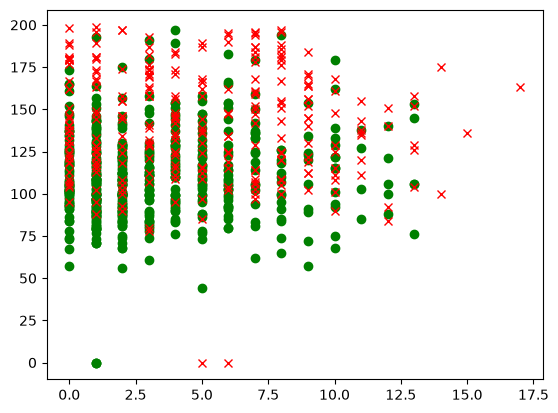

In [4]:
plt.plot(pima[indices0,0], pima[indices0,1], 'go')
plt.plot(pima[indices1,0], pima[indices1,1], 'rx')
plt.show()

In [5]:
data = pima[:,:8]

# pregnancy 
data[ np.where(data[:,0]>8), 0] = 8

# age
max_age, c = np.max(data[:, 7]), 1
print(max_age)
for i in range(20,int(max_age),10):
    data[np.where((data[:,7]>i) & (data[:,7]<=i+10)), 7] = c
    c += 1


print(data)

# normalisation
data = (data - data.mean(axis=0)) / data.var(axis=0)

trainin = data[::2]
testin = data[1::2]

traintgt = pima[::2, 8:9]
testtgt = pima[1::2, 8:9]

trainin_bias = np.concatenate( (trainin, -np.ones( (np.shape(trainin)[0], 1) ) ), axis=1)
testin_bias = np.concatenate( (testin, -np.ones( (np.shape(testin)[0], 1) ) ), axis=1)

print(trainin_bias)

81.0
[[  6.    148.     72.    ...  33.6     0.627   3.   ]
 [  1.     85.     66.    ...  26.6     0.351   2.   ]
 [  8.    183.     64.    ...  23.3     0.672   2.   ]
 ...
 [  5.    121.     72.    ...  26.2     0.245   1.   ]
 [  1.    126.     60.    ...  30.1     0.349   3.   ]
 [  1.     93.     70.    ...  30.4     0.315   1.   ]]
[[ 3.14483148e-01  2.65501131e-02  7.73609020e-03 ...  1.41490137e+00
   8.83829930e-01 -1.00000000e+00]
 [ 5.71696203e-01  6.08330088e-02 -1.36451686e-02 ...  1.82535163e+00
   1.12487446e-01 -1.00000000e+00]
 [-4.57156014e-01  1.57754887e-02 -7.77889448e-02 ...  1.65650764e+01
   1.12487446e-01 -1.00000000e+00]
 ...
 [ 5.71696203e-01 -3.12410539e-02 -1.89904832e-02 ... -3.00884029e+00
   1.12487446e-01 -1.00000000e+00]
 [-1.99942960e-01  1.08281914e-03  2.39077552e-03 ... -1.20285916e+00
  -6.58855039e-01 -1.00000000e+00]
 [-3.28549487e-01  5.00086436e-03 -2.43357979e-02 ... -1.12076911e+00
   8.83829930e-01 -1.00000000e+00]]


## The training algorithm

### The Neuron Bursting

In [6]:
def neuralNetwork(data : list[float], weights : list[float], seuil = 0) -> float :
    linComb = 0
    for i in range(len(data)):
        linComb += data[i] * weights[i]
    
    #print(linComb)
    
    #linComb -= seuil
    #print(linComb)

    # activation function
    return 1.0 if linComb > 0 else 0.0


### The reestimation  

In [7]:
def reestimate(inputs : list[list], weights : list[list], outputs : list[list], mu = 0.1):
    """ inputs = array of vectors
        weight = matrix of all the weights
        threshold = list of threshold
        output = array with each neuron expected output
    """
    # for each vector in the input data 
    for idx, vector in enumerate(inputs) :
        newWeights = list()

        # for each neuron
        for i in range(len(weights)):
            row = list()

            res = 0.0 if  neuralNetwork(vector, weights[i]) < 0.5 else 1.0

            # for each node 
            for j in range(len(weights[0])):
                tmp = weights[i][j] - mu * ( res - outputs[idx][i]) * vector[j]
                row.append(tmp)
            
            newWeights.append(row)

        weights = newWeights.copy() 
        #print(weights)

    return weights               

### Training Loop

In [8]:
def training(inputs : np.array, outputs : np.array, mu = 0.1, show = False):
    nIn, nOut = np.shape(inputs)[1], np.shape(outputs)[1] 
    weights = np.random.rand(nOut, nIn) * 0.1 - 0.05

    old_weights = weights
    for epochs in range(40):
        if show : 
            print(old_weights)
        new_weights = reestimate(inputs, weights, outputs, mu)
        old_weights = new_weights

    return old_weights

In [23]:
final_weights = training(trainin_bias, traintgt)

cpt = 0
rights = 0
for idx, vect in enumerate(testin_bias):
    res = 0.0 if  neuralNetwork(vect, final_weights[0]) < 0.5 else 1.0
    #print(res, "\t expected : ", testtgt[idx][0])
    cpt += 1
    if res == testtgt[idx][0] :
        rights += 1
    
percentage = "%.2f" % (rights/cpt * 100)
print(percentage,"% ", "of the estimations are correct")




66.67 %  of the estimations are correct


# Data Preparation (Normalisation)

* The most common way of preparing the data, is by treating each dimension independently.
* We can prepare the data in two ways, the first is by scaling every column have zero mean and unit variance. The second way, is by scaling them so that the maximum value is 1 and the minimum is -1. This is called data **Normalisation**, or sometimes **standardisation**. 


**Note:** 

We should normalise before splitting the dataset into two

There are 2 methods to improve the results : **Feature Selection** or **Dimensionality Reduction**. 

* Feature Selection : on enleve des colonnes parcequ'elles rajoute du bruit ou aide pas dans l'estimation.
* Dimensionality Reduction : On construit des nouvelles variables en fonction des anciennes.